## Figure 4.1: Hypothesis Similarity Across Attention Heads

Compares head-level hypothesis similarity distributions for each model under baseline, single best-fit, and linearly weighted program settings.

Sentences loaded: ['The rhythmic crash of the waves, breaking against the shore, provided a soothing soundtrack to the quiet evening.', 'He contemplated, for a moment, the vastness of the universe, its endless possibilities, and his tiny place within it.'] ...
Device: cpu

── bert ──────────────────────────────────────────
  Computing baseline for bert...
  Baseline: n=144  mean=14.3%
  Best-single: n=144  mean=48.9%
  All-weighted (k=20): n=144  mean=51.1%

── gpt2 ──────────────────────────────────────────
  Computing baseline for gpt2...
  Baseline: n=144  mean=30.1%
  Best-single: n=144  mean=67.6%
  All-weighted (k=20): n=143  mean=65.4%

── tinyllama ──────────────────────────────────────────
  Computing baseline for tinyllama...
  Baseline: n=704  mean=24.6%
  Best-single: n=704  mean=73.7%
  All-weighted (k=20): n=654  mean=70.9%

All data loaded.


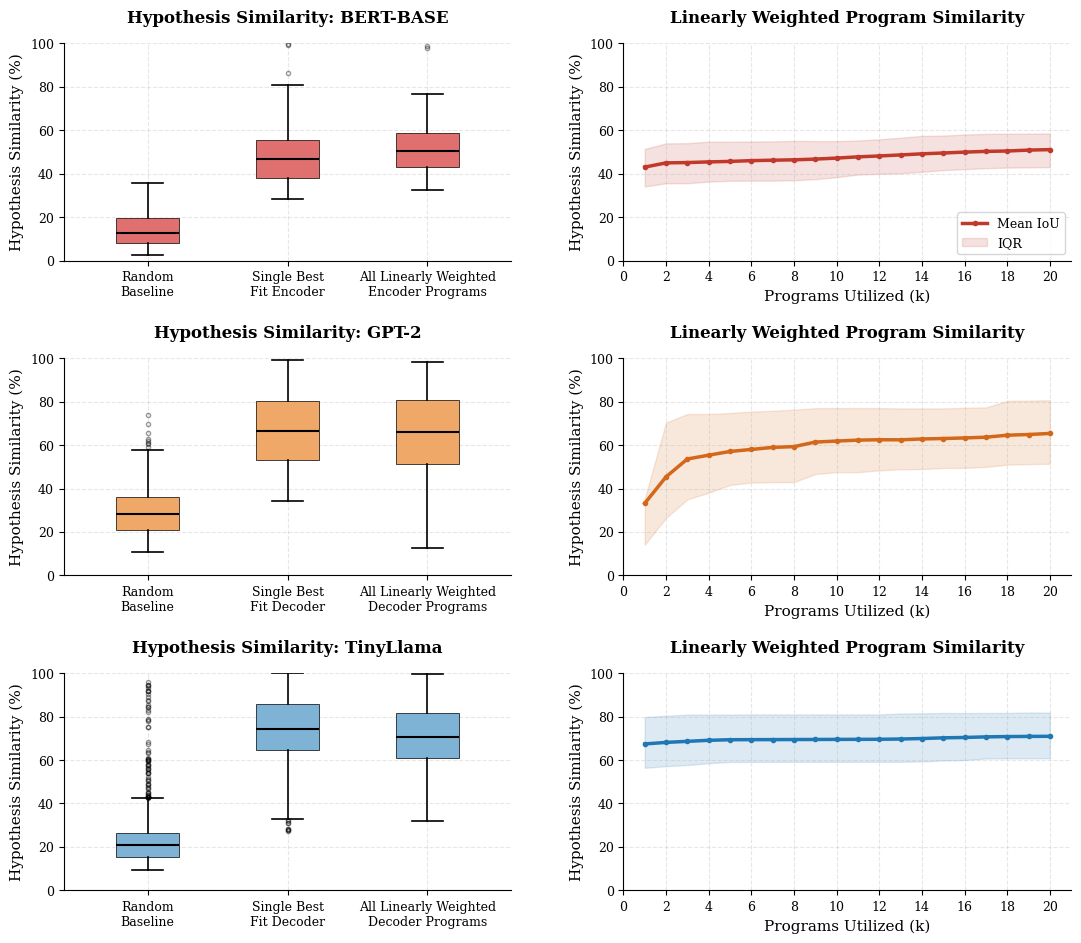


Saved to ../results/plots/figure_4_1.pdf


In [53]:
# ============================================================
#  FIGURE 4.1 — Self-contained plotting cell
#  Assumes local data directory structure:
#    data/iou_scores_{model}.csv
#    data/generic_sentences.json
#    data/interpolation_k_{model}.csv
# ============================================================

# ── 1. Paths ────────────────────────────────────────────────────────────────
import os
DATA_BASE    = "../data"
DATA_DIR     = f"{DATA_BASE}"
RESULTS_DIR  = f"../results"

os.makedirs("../results", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE", "arch": "Encoder",
                  "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",     "arch": "Decoder",
                  "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama", "arch": "Decoder",
                  "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
}

# ── 2. All Imports ───────────────────────────────────────────────────────────────
import sys, random, warnings
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import torch
import inspect
from typing import List, Callable
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

plt.rcParams.update({
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--"
})

# ── 3. IoU helper ────────────────────────────────────────────────────────────
def iou_score(p, q):
    p = np.clip(p, 1e-12, 1.0); q = np.clip(q, 1e-12, 1.0)
    return float(np.minimum(p, q).sum() / np.maximum(p, q).sum())

# ── 4. Compute baseline IoU for a model (uniform lower-diagonal hypothesis) ──
def compute_baseline(hf_name, sentences, device="cpu"):
    """Returns list of per-head mean IoU scores (0–100 scale)."""
    model = AutoModel.from_pretrained(hf_name, output_attentions=True).to(device)
    tok   = AutoTokenizer.from_pretrained(hf_name)
    n_layers = model.config.num_hidden_layers
    n_heads  = model.config.num_attention_heads
    accum = np.zeros(n_layers * n_heads)

    for sent in sentences:
        inputs = tok(sent, return_tensors="pt").to(device)
        with torch.no_grad():
            atts = model(**inputs).attentions
        for l in range(n_layers):
            for h in range(n_heads):
                att = atts[l][0, h].to(torch.float32).cpu().numpy()
                n   = att.shape[0]
                ref = np.tril(np.ones((n, n)))
                ref = ref / ref.sum(axis=1, keepdims=True)
                accum[l * n_heads + h] += np.mean(
                    [iou_score(att[i], ref[i]) for i in range(n)]
                )

    del model, tok
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return (accum / len(sentences) * 100).tolist()

# ── 5. Load the 5 sentences (same sample as training notebook) ───────────────
df_json = pd.read_json(f"{DATA_DIR}/generic_sentences.json")
all_sents = df_json[0].tolist()
rng = random.Random(RANDOM_SEED)
shuffled = all_sents[:]
rng.shuffle(shuffled)
SAMPLE_SENTENCES = shuffled[:5]
print("Sentences loaded:", SAMPLE_SENTENCES[:2], "...")

# ── 6. Build per-model data ──────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

model_results = {}

for key, cfg in MODEL_CONFIGS.items():
    print(f"\n── {key} ──────────────────────────────────────────")

    iou_csv   = f"{DATA_DIR}/iou_scores_{key}.csv"
    interp_csv = f"{DATA_DIR}/interpolation_k_{key}.csv"

    # --- Baseline (computed live) ---
    print(f"  Computing baseline for {key}...")
    baseline_scores = compute_baseline(cfg["hf_name"], SAMPLE_SENTENCES, device=DEVICE)
    print(f"  Baseline: n={len(baseline_scores)}  mean={np.mean(baseline_scores):.1f}%")

    # --- Single best-fit scores (from iou_scores CSV, k=1 equivalent) ---
    best_single = []
    if os.path.exists(iou_csv):
        iou_df = pd.read_csv(iou_csv)
        # Best score per (layer, head) = max iou_score across all programs
        best_per_head = (
            iou_df.groupby(["layer", "head"])["iou_score"]
            .max()
            .reset_index()
        )
        best_single = (best_per_head["iou_score"].dropna() * 100).tolist()
        print(f"  Best-single: n={len(best_single)}  mean={np.mean(best_single):.1f}%")
    else:
        print(f"  [WARN] Missing: {iou_csv}")

    # --- All linearly weighted scores and k-sweep (from interpolation CSV) ---
    all_weighted = []
    k_sweep = {}
    if os.path.exists(interp_csv):
        interp_df = pd.read_csv(interp_csv)
        interp_df["iou_score"] = interp_df["iou_score"] * 100

        max_k = interp_df["k"].max()
        all_weighted = interp_df[interp_df["k"] == max_k]["iou_score"].dropna().tolist()
        print(f"  All-weighted (k={max_k}): n={len(all_weighted)}  mean={np.mean(all_weighted):.1f}%")

        for kval, grp in interp_df.groupby("k"):
            k_sweep[int(kval)] = grp["iou_score"].dropna().tolist()
    else:
        print(f"  [WARN] Missing: {interp_csv} — right column will show placeholder")

    model_results[key] = {
        "box_data": [baseline_scores, best_single, all_weighted],
        "k_sweep":  k_sweep,
    }

print("\nAll data loaded.")

# ── 7. Plot ──────────────────────────────────────────────────────────────────
def styled_boxplot(ax, data, labels, colors, positions):
    valid = [(d, l, p) for d, l, p in zip(data, labels, positions) if len(d) > 0]
    if not valid:
        ax.text(0.5, 0.5, "(no data)", transform=ax.transAxes,
                ha="center", va="center", style="italic", color="#aaa")
        return
    vdata, vlabels, vpos = zip(*valid)
    bp = ax.boxplot(vdata, positions=list(vpos), patch_artist=True, widths=0.45,
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4, linestyle="none"))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_linewidth(0.5)
    ax.set_xticks(list(vpos)); ax.set_xticklabels(list(vlabels))
    ax.set_xlim(min(vpos) - 0.6, max(vpos) + 0.6)

ROW_COLORS = {
    "bert":      {"box": "#e07070", "line": "#c0392b"},
    "gpt2":      {"box": "#f0a868", "line": "#d4681a"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
}

fig = plt.figure(figsize=(13, 11))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.25)

for row, key in enumerate(["bert", "gpt2", "tinyllama"]):
    cfg    = MODEL_CONFIGS[key]
    res    = model_results[key]
    c      = ROW_COLORS[key]
    colors = [c["box"], c["box"], c["box"]]

    # ── LEFT: Boxplot ─────────────────────────────────────────────────────
    ax_box = fig.add_subplot(gs[row, 0])
    labels = [
        "Random\nBaseline",
        f"Single Best\nFit {cfg['arch']}",
        f"All Linearly Weighted\n{cfg['arch']} Programs",
    ]
    styled_boxplot(ax_box, res["box_data"], labels, colors, positions=[1, 2, 3])
    ax_box.set_title(f"Hypothesis Similarity: {cfg['display']}", fontweight="bold", pad=15)
    ax_box.set_ylabel("Hypothesis Similarity (%)")
    ax_box.set_ylim(0, 100)

    # ── RIGHT: Line chart with IQR shading ───────────────────────────────
    ax_line = fig.add_subplot(gs[row, 1])
    ax_line.set_title("Linearly Weighted Program Similarity", fontweight="bold", pad=15)
    ax_line.set_xlabel("Programs Utilized (k)")
    ax_line.set_ylabel("Hypothesis Similarity (%)")
    ax_line.set_ylim(0, 100)

    if res["k_sweep"]:
        ks   = sorted(res["k_sweep"].keys())
        means = [np.mean(res["k_sweep"][k]) for k in ks]
        p25   = [np.percentile(res["k_sweep"][k], 25) for k in ks]
        p75   = [np.percentile(res["k_sweep"][k], 75) for k in ks]
        ax_line.plot(ks, means, color=c["line"], linewidth=2.5,
                      marker="o", markersize=3, label="Mean IoU")
        ax_line.fill_between(ks, p25, p75, color=c["line"], alpha=0.15, label="IQR")
        ax_line.set_xlim(0, max(ks) + 1)
        ax_line.set_xticks(range(0, max(ks) + 2, 2))
        if row == 0:
            ax_line.legend(loc="lower right")
    else:
        ax_line.set_xlim(0, 20); ax_line.set_xticks(range(0, 21, 2))
        ax_line.text(0.5, 0.5, "(coming soon)", transform=ax_line.transAxes,
                      ha="center", va="center", style="italic", color="#aaa")

for ax in fig.axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

out_path = f"{RESULTS_DIR}/plots/figure_4_1.pdf"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.savefig
plt.show()
print(f"\nSaved to {out_path}")

## Figure 4.2: Best-Fit Program Mapping by Head

Maps each attention head to its highest-IoU hypothesis program and visualizes category-aware patterns across layers and heads.

In [ ]:
# ============================================================
# Figure 4.2 data prep: build/read best-fit CSVs per model
# Expected paths:
#   ../data/iou_scores_{model}.csv
#   ../results/program_categories.json
# ============================================================

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from data import golden_programs
all_programs: List[Callable] = [
    obj for name, obj in inspect.getmembers(golden_programs, inspect.isfunction)
]

# Program categories prepared offline
with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)

# Verification of programs
total_count = sum(len(v) for v in attention_head_categories.values())
print(f"[INFO] Programs loaded: {len(all_programs)}")
print(f"[INFO] Programs categorized: {total_count}")

for model_key in MODEL_CONFIGS.keys():
    iou_csv = f"{DATA_DIR}/iou_scores_{model_key}.csv"
    if not os.path.exists(iou_csv):
        print(f"[WARN] Missing: {iou_csv}. Skipping best-fit generation for {model_key}.")
        continue

    # Skip if best-fit CSV already exists
    out_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(out_csv):
        print(f"[INFO] Already exists: {out_csv}. Skipping best-fit generation for {model_key}.")
        continue

    iou_df = pd.read_csv(iou_csv)
    iou_df = iou_df.groupby(["layer", "head", "program_idx"])["iou_score"].mean().reset_index()

    n_best_programs = 1
    best_fits = (
        iou_df.groupby(["layer", "head"])
        .apply(lambda g: g.nlargest(n_best_programs, "iou_score"))
        .reset_index(drop=True)
    )

    best_fits["iou_score"] = best_fits["iou_score"].round(3)
    best_fits.to_csv(out_csv, index=False)
    print(f"[DONE] Saved best fits for {model_key} to {out_csv}")

best_fits_bert = []
best_fits_gpt2 = []
best_fits_tinyllama = []

for model_key in MODEL_CONFIGS.keys():
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(best_fits_csv):
        df = pd.read_csv(best_fits_csv)
        if model_key == "bert":
            best_fits_bert = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        elif model_key == "gpt2":
            best_fits_gpt2 = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        elif model_key == "tinyllama":
            best_fits_tinyllama = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        print(f"[INFO] Loaded best fits for {model_key} from {best_fits_csv}")
    else:
        print(f"[WARN] Missing: {best_fits_csv}. Cannot load best fits for {model_key}.")

71 programs loaded.
Total programs categorized: 71
  [INFO] Already exists: ../results/best_fits_bert.csv — skipping best fits for bert
  [INFO] Already exists: ../results/best_fits_gpt2.csv — skipping best fits for gpt2
  [INFO] Already exists: ../results/best_fits_tinyllama.csv — skipping best fits for tinyllama
  Loaded best fits for bert from ../results/best_fits_bert.csv
  Loaded best fits for gpt2 from ../results/best_fits_gpt2.csv
  Loaded best fits for tinyllama from ../results/best_fits_tinyllama.csv


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# Standardized Colormap: 0-40% White, 40-100% transitions to Dark Charcoal
colors = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list("custom_gray", list(zip(nodes, colors)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#001D3D",
    "relational_and_semantic":       "#4A90E2",
    "special_tokens_and_boundaries": "#7FF1F5",
    "linguistic_and_syntactic":      "#274C77",
    "sequential_and_induction":      "#0077B6",
    "uniformity_and_global":         "#95D5EE",
}

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335", 
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4", 
}

all_names = [func.__name__ for func in all_programs]
os.makedirs("../results/plots/figure_4_2", exist_ok=True)

def save_heatmap(data, title, best_fits, all_names, filename, categories=None):
    n_rows, n_cols = data.shape
    fig_w = n_cols * 0.45 + 1.2
    fig_h = n_rows * 0.45 + 1.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    reversed_data = data[::-1]
    sns.heatmap(reversed_data, ax=ax, cmap=standard_prec_map, cbar=False,
                linewidths=0.5, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)

    name_to_cat = get_name_to_category(categories) if categories else {}

    if best_fits is not None:
        for i, (head_id, name, score) in enumerate(best_fits):
            layer_val = i // n_cols
            x = i % n_cols
            y_pos = (n_rows - 1) - layer_val
            cell_value = data[layer_val, x] # The accuracy value for this cell

            if name:
                legend_idx = all_names.index(name) if name in all_names else head_id
                cat = name_to_cat.get(name, None)
                color = CATEGORY_COLORS.get(cat, "#333333")

                # Change 1: Text color dependent on background accuracy
                # If accuracy is high (dark background), use white text for visibility
                text_color = "white" if cell_value > 0.7 else "black"

                ax.add_patch(plt.Circle((x + 0.5, y_pos + 0.5), radius=0.3,
                                        facecolor='none', edgecolor=color,
                                        linewidth=3.5, zorder=3))

                ax.text(x + 0.5, y_pos + 0.5, str(legend_idx),
                        ha='center', va='center', color=text_color,
                        fontweight='bold', fontsize=8, zorder=4)

    # Change 2: Precision spacing beneath title using 'pad'
    ax.set_title(title, fontweight='bold', fontsize=11, color='#001D3D', pad=5)
    ax.set_yticklabels(range(n_rows - 1, -1, -1), rotation=0, fontsize=7)
    ax.set_xticklabels(range(n_cols), fontsize=7)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def save_shared_colorbar(filename):
    # Change 3: Significantly thinner plot and removed helper text
    fig, ax = plt.subplots(figsize=(10, 0.15))
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
                      cax=ax, orientation='horizontal')
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=7)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

# 1. Generate the three main model heatmaps
# These now feature hollow thick rings and dynamic text contrast
n_layers, n_heads = 12, 12
bert_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_bert):
    layer, head = i // n_heads, i % n_heads
    if score is not None: bert_data[layer, head] = score

n_layers, n_heads = 12, 12
gpt2_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_gpt2):
    layer, head = i // n_heads, i % n_heads
    if score is not None: gpt2_data[layer, head] = score

n_layers, n_heads = 22, 32
tinyllama_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_tinyllama):
    layer, head = i // n_heads, i % n_heads
    if score is not None: tinyllama_data[layer, head] = score

save_heatmap(bert_data, "BERT-BASE",
             best_fits_bert, all_names, "../results/plots/figure_4_2/fig_bert.png",
             categories=attention_head_categories)

save_heatmap(gpt2_data, "GPT-2",
             best_fits_gpt2, all_names, "../results/plots/figure_4_2/fig_gpt.png",
             categories=attention_head_categories)

save_heatmap(tinyllama_data, "TINY LLAMA",
             best_fits_tinyllama, all_names, "../results/plots/figure_4_2/fig_tinyllama.png",
             categories=attention_head_categories)

# 2. Generate the Ultra-Thin Shared Colorbar
# Place this at the very bottom of your figure grid in your document
save_shared_colorbar("../results/plots/figure_4_2/fig_shared_colorbar.png")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors

def get_text_color(hex_color):
    """Returns 'black' for light colors and 'white' for dark colors."""
    rgb = mcolors.to_rgb(hex_color)
    # Standard formula for relative luminance
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if luminance > 0.5 else 'white'

def save_category_boxes(filename):
    n_cats = len(CATEGORY_COLORS)
    fig, axes = plt.subplots(1, n_cats, figsize=(14, 1.2))
    fig.subplots_adjust(wspace=0.15)

    for ax, (group, color) in zip(axes, CATEGORY_COLORS.items()):
        ax.axis('off')

        # Draw the rounded box
        rect = mpatches.FancyBboxPatch(
            (0.05, 0.1), 0.9, 0.8,
            boxstyle="round,pad=0,rounding_size=0.15",
            color=color, transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)

        # 1. ADD LOGIC HERE: Determine text color based on background luminance
        t_color = get_text_color(color)

        clean_name = group.replace('_', ' ').title().replace(' And', '\nAnd')

        # 2. UPDATE TEXT CALL: Use the dynamic t_color
        ax.text(0.5, 0.5, clean_name,
                color=t_color, ha='center', va='center',
                fontweight='bold', fontsize=10, transform=ax.transAxes,
                linespacing=1.5)

    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.close()

# 2. Filtered Legend Only including programs present in the matrices
def save_filtered_legend(all_names, filename, categories, best_fits_list):
    """
    best_fits_list: list of lists, e.g., [best_fits_bert, best_fits_gpt, best_fits_tinyllama]
    """
    # Identify unique names that actually appeared in the matrices
    appeared_names = set()
    for fits in best_fits_list:
        if fits is not None:
            for head_id, name, score in fits:
                if name is not None:
                    appeared_names.add(name)

    # Filter and sort by original index to keep numbering consistent
    filtered_programs = [(i, name) for i, name in enumerate(all_names) if name in appeared_names]

    if not filtered_programs:
        print("No programs found in matrices. Skipping legend.")
        return

    n_cols = 4
    n_rows = int(np.ceil(len(filtered_programs) / n_cols))
    fig, ax = plt.subplots(figsize=(14, n_rows * 0.3))
    ax.axis('off')

    # Set the title with consistent professional blue and padding
    ax.set_title("Hypothesis Programs: Performance-Aligned Functional Proxies\n",
                 fontweight='bold', fontsize=11, color='black', pad=15)

    name_to_cat = get_name_to_category(categories)

    for i, (original_idx, name) in enumerate(filtered_programs):
        col, row = i // n_rows, i % n_rows
        x, y = col * (1/n_cols), 1 - (row * (1/n_rows))
        cat = name_to_cat.get(name)
        color = CATEGORY_COLORS.get(cat, "#333333")

        # Consistent numbering based on the original all_names list
        ax.text(x, y, f"○ {original_idx}: {name}", color=color, fontsize=8,
                fontfamily='monospace', transform=ax.transAxes)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {filename} with {len(filtered_programs)} programs.")

# --- Call sequence ---
save_category_boxes("../results/plots/figure_4_2/fig_group_map.png")

# Pass all three best_fits lists to filter the legend
save_filtered_legend(
    all_names,
    "../results/plots/figure_4_2/fig_program_index.png",
    attention_head_categories,
    [best_fits_bert, best_fits_gpt2, best_fits_tinyllama]
)

Saved ../results/plots/figure_4_2/fig_program_index.png with 22 programs.


## Figure 4.3: Perplexity Impact of Head Replacement

Shows normalized perplexity increase as progressively more attention heads are replaced with symbolic hypothesis programs.

In [4]:
def prepare_sentence(sent, mode="random"):
    words = sent.split()
    if len(words) <= 3:
        return sent
        
    if mode == "random":
        idx = np.random.randint(3, len(words))
        return " ".join(words[:idx])
    elif mode == "last_word":
        return " ".join(words[:-1])
    else:
        return sent

def run_replacement_experiment_gpt2(
    sentences,
    best_fits_df,
    all_programs,
    strategy="baseline",
    max_heads=144,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import GPT2LMHeadModel, GPT2Tokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    # --- Baseline ---
    print("Calculating baseline perplexities...")
    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    base_model.eval()
    baseline_ppls, baseline_logits = [], []

    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])

    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads: break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model_k.eval()

        if strategy == "baseline": hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "smart": hook_fn = make_smart_hook(trial_lookup, all_programs)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(trial_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(12):
            target = model_k.transformer.h[l_idx].attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.transformer.h[l_idx].attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                log_probs_new = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
                probs_baseline = F.softmax(baseline_logits[i], dim=-1)
                kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

        for handle in hook_handles: handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/gpt2_{strategy}.csv", index=False)
    return results_df


import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import BertForMaskedLM, AutoTokenizer, logging as hf_logging

def full_perplexity(sentence, bert_model, tokenizer, device):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.shape[1]
    log_probs = []
    for i in range(1, seq_len - 1):  # skip [CLS] and [SEP]
        masked = input_ids.clone()
        masked[0, i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = bert_model(masked).logits
        prob = torch.log_softmax(logits[0, i], dim=-1)[input_ids[0, i]]
        log_probs.append(prob)
    return torch.exp(-torch.stack(log_probs).mean()).item()

def run_replacement_experiment_bert(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=144,
    num_sentences=5,
    bert_model_name="bert-base-uncased",
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import ast
    hf_logging.set_verbosity_error()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []
    models = {}

    # --- Baseline ---
    print("Calculating baseline pseudo-perplexities...")
    base_model = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
    base_model.eval()
    baseline_ppls = [full_perplexity(s, base_model, tokenizer, device) for s in eval_sentences]
    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean pseudo-PPL: {np.mean(baseline_ppls):.2f}")

    print(f"\n=== STRATEGY: {strategy.upper()} ===\n")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
            except (KeyError, IndexError, ValueError) as e:
                print(f"  [WARN] Could not resolve program for head {head_tuple}: {e}")
                prog_name = None

            if prog_name:
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)

    print(f"Total heads to replace: {len(unique_heads_mapping)}")

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            attn_mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(attn_mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                if hypo_tensor.shape == (seq_len, seq_len):
                                    modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_key = f"model_v{k}"
        models[model_key] = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
        models[model_key].eval()

        if strategy == "baseline":
            hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "sanity_check":
            hook_fn = make_sanity_check_hook(trial_lookup)
        else:
            hook_fn = make_smart_hook(trial_lookup, all_programs)

        hook_handles = []
        for l_idx in range(12):
            target = models[model_key].bert.encoder.layer[l_idx].attention.self
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls = []
        for sent in eval_sentences:
            for l_idx in relevant_layers:
                models[model_key].bert.encoder.layer[l_idx].attention.self._current_sentence = sent
            replaced_ppls.append(full_perplexity(sent, models[model_key], tokenizer, device))

        for handle in hook_handles:
            handle.remove()
        del models[model_key]
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k,
            "head": str(candidate[0]),
            "program": candidate[1][0],
            "strategy": strategy,
            "increase": mean_pct,
            "spike": is_spike,
        })
        print(f"k={k:02d} | New Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/bert_{strategy}.csv", index=False)
    return results_df


def run_replacement_experiment_llama(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=250,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import copy
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
    NUM_LAYERS, NUM_HEADS, HIDDEN_SIZE = 22, 32, 2048
    HEAD_DIM = HIDDEN_SIZE // NUM_HEADS

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    print("Loading reference model...")
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
    ref_model.eval()

    print("Calculating baseline perplexities...")
    baseline_ppls, baseline_logits = [], []
    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        iteration_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in iteration_lookup)

        iter_model = copy.deepcopy(ref_model)
        iter_model.eval()

        if strategy == "smart": hook_fn = make_smart_hook(iteration_lookup, all_programs)
        elif strategy == "baseline": hook_fn = make_baseline_hook(iteration_lookup)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(iteration_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(NUM_LAYERS):
            target = iter_model.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                iter_model.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = iter_model(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(F.kl_div(
                    F.log_softmax(out_rep.logits[:, -1, :], dim=-1),
                    F.softmax(baseline_logits[i], dim=-1),
                    reduction='batchmean'
                ).item())

        for handle in hook_handles: handle.remove()
        del iter_model
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    if save_file:
        pd.DataFrame(experiment_results).to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        pd.DataFrame(experiment_results).to_csv(f"../results/replacement_run/tinyllama_{strategy}.csv", index=False)
    del ref_model
    return pd.DataFrame(experiment_results)

In [ ]:
# ============================================================
# Run head replacement experiments per model
# Expected paths:
#   ../results/best_fits_{model}.csv
#   ../data/generic_sentences.json
# ============================================================

df_generic = pd.read_json("../data/generic_sentences.json")
generic_sentences = df_generic[0].tolist()

for model_key, cfg in MODEL_CONFIGS.items():
    print(f"\n[INFO] Running replacement for {model_key}")
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if not os.path.exists(best_fits_csv):
        print(f"[WARN] Missing: {best_fits_csv}. Skipping {model_key}.")
        continue

    best_fits_df = pd.read_csv(best_fits_csv)
    best_fits_df = best_fits_df.sort_values(by="iou_score", ascending=False).reset_index(drop=True)

    if model_key == "bert":
        bert_smart = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="smart")
        bert_baseline = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "gpt2":
        gpt2_smart = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="smart")
        gpt2_baseline = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "tinyllama":
        tinyllama_smart = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="smart")
        tinyllama_baseline = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    else:
        print(f"[WARN] No replacement function defined for {model_key}. Skipping.")

print("\n[DONE] Replacement experiment sweep complete.")


── Running replacement for bert ──
Calculating baseline pseudo-perplexities...
Baseline complete. Mean pseudo-PPL: 3.05

=== STRATEGY: SMART ===

Total heads to replace: 144
Running with strategy='smart', skip_spikes=True
k=01 | New Head: (2, 0) | Program: next_attention | Mean PPL Inc: 2.3421%
k=02 | New Head: (8, 2) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 2.4239%
k=03 | New Head: (1, 6) | Program: sentence_beginning_salience | Mean PPL Inc: 2.2024%
k=04 | New Head: (5, 1) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 2.8294%
k=05 | New Head: (0, 0) | Program: parenthetical_insertion | Mean PPL Inc: 2.6912%
k=06 | New Head: (7, 6) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 3.1468%
k=07 | New Head: (8, 6) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 3.6179%
k=08 | New Head: (4, 3) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 4.0355%
k=09 | New Head: (7, 7) | Program: emphasize_verbs_and_objects | Mean PPL Inc: 4.2489%
k=10 | New 

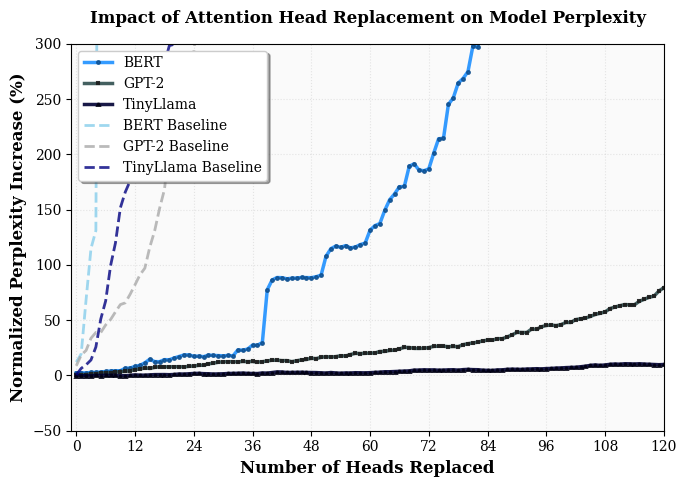

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Data points - X-axis: 0 to 35 (36 total)
MAX_X = 128
x = np.arange(MAX_X)

total_heads_bert = 144
total_heads_gpt2 = 144
total_heads_tinyllama = 704

bert_file = "../results/replacement_run/bert_smart.csv"
gpt2_file = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file = "../results/replacement_run/tinyllama_smart.csv"
bert_baseline_file = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"

bert = np.pad(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2 = np.pad(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X])), constant_values=1050)
tiny_llama = np.pad(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X])), constant_values=1050)
bert_baseline = np.pad(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2_baseline = np.pad(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
tinyllama_baseline = np.pad(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X])), constant_values=1050)

# Plotting lines
ax.plot(x, bert, color='#1E90FF', linewidth=2.5, label='BERT', marker='o',
        markersize=2, markerfacecolor='#1E90FF', markeredgewidth=1.5,
        markeredgecolor='#104E8B', alpha=0.9)

ax.plot(x, gpt2, color='#2F4F4F', linewidth=2.5, label='GPT-2', marker='s',
        markersize=2, markerfacecolor='#2F4F4F', markeredgewidth=1.5,
        markeredgecolor='#1C1C1C', alpha=0.9)

# TinyLlama (dark dark blue)
ax.plot(x, tiny_llama, color='#000033', linewidth=2.5, label='TinyLlama', marker='^',
        markersize=2, markerfacecolor='#000033', markeredgewidth=1.5,
        markeredgecolor='#000011', alpha=0.9)

# Baselines
ax.plot(x, bert_baseline, color='#87CEEB', linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x, gpt2_baseline, color='#A9A9A9', linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x, tinyllama_baseline, color='#000080', linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)

# Labels and Title
ax.set_xlabel('Number of Heads Replaced', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

# Limits and Grid
Y_LIM = 250
ax.set_xlim(-1, 36)
ax.set_ylim(-50, Y_LIM)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

# Ticks
ax.set_xticks(np.arange(0, MAX_X + 1, 12))
ax.set_yticks(np.arange(-50, Y_LIM + 100, 50))

# Legend and background
ax.legend(loc='upper left', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')

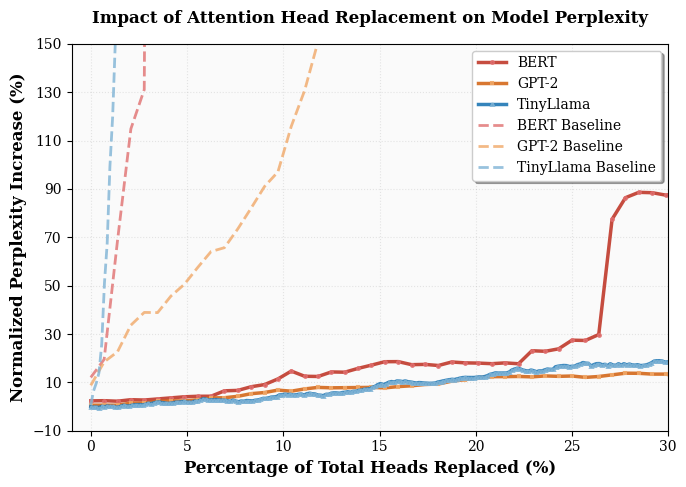

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Color mapping (consistent with Figure 4.1)
ROW_COLORS = {
    "bert":      {"box": "#e07070", "line": "#c0392b"},
    "gpt2":      {"box": "#f0a868", "line": "#d4681a"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
}

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Constants
MAX_X = 250
x_raw = np.arange(MAX_X)

total_heads_bert = 144
total_heads_gpt2 = 144
total_heads_tinyllama = 704

# Calculate percentage X-axes for each model
x_bert_pct = (x_raw / total_heads_bert) * 100
x_gpt2_pct = (x_raw / total_heads_gpt2) * 100
x_tinyllama_pct = (x_raw / total_heads_tinyllama) * 100

# File paths
bert_file = "../results/replacement_run/bert_smart.csv"
gpt2_file = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file = "../results/replacement_run/tinyllama_smart.csv"
bert_baseline_file = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"

# Helper function to load data
def load_data(file):
    data = pd.read_csv(file)["increase"].values[:MAX_X]
    return np.pad(data, (0, MAX_X - len(data)), constant_values=1050)

# load in all csv shuffles in ../results/replacement_run/shuffles
all_shuffles = {} # model_key => [[]]
for f in os.listdir("../results/replacement_run/shuffles"):
    if f.startswith("bert_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("bert") is None: 
            all_shuffles["bert"] = []
        all_shuffles["bert"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))
    elif f.startswith("gpt2_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("gpt2") is None: 
            all_shuffles["gpt2"] = []
        all_shuffles["gpt2"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))
    elif f.startswith("tinyllama_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("tinyllama") is None: 
            all_shuffles["tinyllama"] = []
        all_shuffles["tinyllama"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))

bert = load_data(bert_file)
gpt2 = load_data(gpt2_file)
tiny_llama = load_data(tinyllama_file)
bert_baseline = load_data(bert_baseline_file)
gpt2_baseline = load_data(gpt2_baseline_file)
tinyllama_baseline = load_data(tinyllama_baseline_file)

# Plotting lines with individual percentage x-coordinates
ax.plot(x_bert_pct, bert, color=ROW_COLORS["bert"]["line"], linewidth=2.5, label='BERT', marker='o',
        markersize=2, markerfacecolor=ROW_COLORS["bert"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["bert"]["box"], alpha=0.9)

ax.plot(x_gpt2_pct, gpt2, color=ROW_COLORS["gpt2"]["line"], linewidth=2.5, label='GPT-2', marker='s',
        markersize=2, markerfacecolor=ROW_COLORS["gpt2"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["gpt2"]["box"], alpha=0.9)

ax.plot(x_tinyllama_pct, tiny_llama, color=ROW_COLORS["tinyllama"]["line"], linewidth=2.5, label='TinyLlama', marker='^',
        markersize=2, markerfacecolor=ROW_COLORS["tinyllama"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["tinyllama"]["box"], alpha=0.9)

# Baselines (lighter/dashed version using box color)
ax.plot(x_bert_pct, bert_baseline, color=ROW_COLORS["bert"]["box"], linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x_gpt2_pct, gpt2_baseline, color=ROW_COLORS["gpt2"]["box"], linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x_tinyllama_pct, tinyllama_baseline, color=ROW_COLORS["tinyllama"]["box"], linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)

# Labels and Title
ax.set_xlabel('Percentage of Total Heads Replaced (%)', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

# Limits and Grid
ax.set_xlim(-1, 30) 
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

# Ticks (every 5%)
ax.set_xticks(np.arange(0, 31, 5))
ax.set_yticks(np.arange(-10, 151, 20))

# Legend and background
ax.legend(loc='upper right', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')

## Final Table: Downstream Task Accuracy Under Head Replacement

Reports benchmark performance across replacement settings to quantify downstream behavior changes after hypothesis-based head substitution.

In [28]:
# ============================================================
#  Run head replacement experiments
#  Assumes local data directory structure:
#    data/iou_scores_{model}.csv
#    data/generic_sentences.json
#    data/interpolation_k_{model}.csv
# ============================================================

np.random.seed(42)

def constrained_shuffle_df(df, sigma=2.0):
    """
    Shuffles the rows of a DataFrame based on their original 
    index position plus some Gaussian noise.
    """
    temp_df = df.copy().reset_index(drop=True)
    noise = np.random.normal(0, sigma, size=len(temp_df))
    temp_df['shuffle_pos'] = temp_df.index + noise
    shuffled_df = temp_df.sort_values('shuffle_pos').drop(columns=['shuffle_pos'])
    return shuffled_df.reset_index(drop=True)

n_shuffles = 10
os.makedirs("../results/replacement_run/shuffles", exist_ok=True)

for model_key in MODEL_CONFIGS.keys():
    if model_key == "bert": continue
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    
    if not os.path.exists(best_fits_csv):
        print(f"  [WARN] Missing: {best_fits_csv} — skipping shuffle for {model_key}")
        continue

    original_best_fits = pd.read_csv(best_fits_csv)
    # sort original best fits by best (highest) iou score to bias towards good programs
    original_best_fits = original_best_fits.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
    
    for idx in range(n_shuffles):
        print(f"\n── Running replacement for {model_key} with shuffle {idx+1} ──")
        shuffled_best_fits_df = constrained_shuffle_df(original_best_fits, sigma=2.0)

        save_path = f"../results/replacement_run/shuffles/{model_key}_smart_shuffle_{idx+1}.csv"

        if model_key == "bert":
            run_replacement_experiment_bert(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "gpt2":
            run_replacement_experiment_gpt2(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "tinyllama":
            run_replacement_experiment_llama(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)


── Running replacement for gpt2 with shuffle 1 ──
Calculating baseline perplexities...
Baseline complete. Mean PPL: 43.41
Running with strategy='smart', skip_spikes=True
k=01 | Head: (7, 2) | Program: initial_element_reinforcement | Mean PPL Inc: 0.0000%
k=02 | Head: (5, 1) | Program: cls_attention | Mean PPL Inc: 0.5649%
k=03 | Head: (6, 9) | Program: initial_element_reinforcement | Mean PPL Inc: 0.5649%
k=04 | Head: (9, 9) | Program: sentence_beginning_salience | Mean PPL Inc: 0.5127%
k=05 | Head: (7, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 1.2943%
k=06 | Head: (4, 11) | Program: previous_attention | Mean PPL Inc: 2.1236%
k=07 | Head: (10, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6371%
k=08 | Head: (10, 8) | Program: sentence_beginning_salience | Mean PPL Inc: 2.5862%
k=09 | Head: (9, 11) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6843%
k=10 | Head: (9, 6) | Program: sentence_beginning_salience | Mean PPL Inc: 2.8924%
k=11 | Head: